# EX4 — Subgroup loss comparison: `std_trial_036` vs `feat_trial_015`

Compare the two best-performing models from EX1 and EX3 across patient subgroups on
the 113-patient test set. Subgroups are defined exactly as in
`feature_split_analysis.ipynb` (cell 24): `pd.qcut(q=4, duplicates='drop')` on every
continuous feature, native levels on categorical/binary features.

**Models**
- `std`  — `out/std_trial_036/dice_results.csv` (EX1 best standard UNet)
- `film` — `out/ex3/bayes_search/feat_trial_015/dice_results.csv` (EX3 best FILM model, uses 22 aggregated features)

**Loss compared:** `ssim_l1_loss = 0.8 * ssim_loss + 0.2 * l1_loss` (the actual
training objective; see `utils/model_utils/loss_functions.py:12-17`).

**Two matrices produced:**
- **Matrix A** — subgroups over *all* health + FastSurfer features
- **Matrix B** — subgroups restricted to the 22 features FILM uses (from `selection.json`)


In [502]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '.')

# Match analyse_results.py colour conventions for the two model families
STD_COLOR  = '#4C72B0'   # FAMILY_PALETTE['std']
FILM_COLOR = '#17A2B8'   # FAMILY_PALETTE['feat']

PROJECT_ROOT  = Path('.')
STD_DIR       = PROJECT_ROOT / 'out' / 'std_trial_036'
FILM_DIR      = PROJECT_ROOT / 'out' / 'ex3' / 'bayes_search' / 'feat_trial_015'
META_PATH     = PROJECT_ROOT / 'data' / 'metadata' / 'metadata_combined.csv'
FIG_DIR       = PROJECT_ROOT / 'out' / 'overleaf_figures' / 'ex4'
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_MIN = 10  # subgroup-size threshold below which we grey out / drop a cell


## 1 — Load per-patient losses

Both `dice_results.csv` files store the component losses (`ssim_loss`, `l1_loss`).
Reconstruct the combined training loss as `0.8 * ssim + 0.2 * l1`.

In [503]:
def _load_losses(csv_path: Path, model_name: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['ssim_l1_loss'] = 0.8 * df['ssim_loss'] + 0.2 * df['l1_loss']
    df['model'] = model_name
    df['hunt_id'] = df['patient_id'].astype(str).str.zfill(5)
    return df

std_df  = _load_losses(STD_DIR  / 'dice_results.csv', 'std')
film_df = _load_losses(FILM_DIR / 'dice_results.csv', 'film')

losses = pd.concat([std_df, film_df], ignore_index=True)
print(f'std  : {len(std_df):3d} patients  | mean ssim_l1_loss = {std_df.ssim_l1_loss.mean():.4f}')
print(f'film : {len(film_df):3d} patients  | mean ssim_l1_loss = {film_df.ssim_l1_loss.mean():.4f}')

shared = set(std_df.hunt_id) & set(film_df.hunt_id)
assert len(shared) == len(std_df) == len(film_df),     f'patient sets diverge — std={len(std_df)} film={len(film_df)} shared={len(shared)}'
print(f'shared patients: {len(shared)}')

losses.head()


std  : 113 patients  | mean ssim_l1_loss = 0.0532
film : 113 patients  | mean ssim_l1_loss = 0.0514
shared patients: 113


,patient_id,dice_GM,dice_WM,dice_CSF,vs_GM,vs_WM,vs_CSF,ssim_loss,l1_loss,ssim_l1_loss,model,hunt_id
0,14968,0.522361,0.660252,0.686125,0.972077,0.972260,0.902245,0.048538,0.012954,0.041421,std,14968
1,16086,0.694747,0.808685,0.843904,0.978906,0.999758,0.941284,0.179039,0.026914,0.148614,std,16086
2,14487,0.745975,0.850233,0.745708,0.983202,0.956383,0.765941,0.125362,0.022149,0.104719,std,14487
3,20391,0.769413,0.858980,0.933451,0.998574,0.982705,0.980656,0.107864,0.022252,0.090741,std,20391
4,25219,0.783118,0.878766,0.756825,0.982956,0.964755,0.771572,0.097002,0.018634,0.081328,std,25219


## 2 — Load patient metadata and recover categorical levels

`metadata_combined.csv` is min-max normalised and one-hot encoded. For subgroup
labelling we need:
- the **single integer level** for each one-hot-encoded categorical
- the raw 0/1 for binary features
- the normalised continuous values (qcut is rank-based so this is fine)


In [504]:
meta = pd.read_csv(META_PATH, dtype={'hunt_id': str})
meta['hunt_id'] = meta['hunt_id'].str.zfill(5)
print(f'metadata: {len(meta)} subjects × {len(meta.columns)} columns')

def _recover_categorical(df: pd.DataFrame, prefix: str) -> pd.Series:
    """Return the integer level for a one-hot-encoded categorical."""
    onehot_cols = sorted([c for c in df.columns if c.startswith(prefix + '_')])
    levels      = [int(c.split('_')[-1]) for c in onehot_cols]
    arr         = df[onehot_cols].values
    # argmax picks the active level; if a row is all-zeros (missing) -> NaN
    active_mask = arr.sum(axis=1) > 0
    out         = np.full(len(df), np.nan)
    out[active_mask] = np.array(levels)[arr[active_mask].argmax(axis=1)]
    return pd.Series(out, index=df.index, name=prefix)

for prefix in ['Healt@NT3BLQ1', 'SmoStat@NT3BLQ1', 'Educ@NT2BLQ1']:
    meta[prefix] = _recover_categorical(meta, prefix)

# Inner-join to the 113 test patients
test_ids = sorted(set(losses['hunt_id']))
meta_test = meta[meta['hunt_id'].isin(test_ids)].reset_index(drop=True)
print(f'test-set metadata join: {len(meta_test)} / {len(test_ids)} patients')
assert len(meta_test) == len(test_ids), 'missing metadata for some test patients'
meta_test.head()


metadata: 731 subjects × 39 columns
test-set metadata join: 113 / 113 patients


,hunt_id,Sex,BirthYear,DiaEv@NT3BLQ1,SmoPackYrs@NT3BLQ1,WaistCirc@NT3BLM,HipCirc@NT3BLM,BPDiasMn23@NT3BLM,BPSystMn23@NT3BLM,SeGluNonFast@NT3BLM,...,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total,Healt@NT3BLQ1,SmoStat@NT3BLQ1,Educ@NT2BLQ1
0,18098,1,0.9375,0,0.000000,0.323944,0.422222,0.347222,0.381818,0.317164,...,0.734502,0.801821,0.790036,0.554041,0.663868,0.719455,0.791585,4.0,0.0,4.0
1,24767,1,0.3125,0,0.043478,0.647887,0.644444,0.319444,0.418182,0.220149,...,0.548511,0.561012,0.542995,0.530874,0.593733,0.437464,0.630223,3.0,1.0,2.0
2,16918,0,0.5625,0,0.139130,0.478873,0.600000,0.597222,0.418182,0.261194,...,0.661541,0.683938,0.571752,0.460532,0.410026,0.598097,0.630711,2.0,1.0,2.0
3,24958,0,0.9375,0,0.156522,0.309859,0.466667,0.138889,0.200000,0.257463,...,0.556920,0.701278,0.492465,0.545840,0.590961,0.578905,0.579656,4.0,1.0,5.0
4,23686,0,0.3750,0,0.222609,0.478873,0.444444,0.111111,0.290909,0.201493,...,0.484304,0.721842,0.563016,0.534799,0.501235,0.638034,0.527528,2.0,1.0,2.0


## 3 — Feature type classification

Identical to `feature_split_analysis.ipynb` cell `cfg`, extended with FastSurfer
brain features (all continuous).

In [505]:
CONTINUOUS_HEALTH = [
    'BirthYear', 'SmoPackYrs@NT3BLQ1', 'WaistCirc@NT3BLM', 'HipCirc@NT3BLM',
    'BPDiasMn23@NT3BLM', 'BPSystMn23@NT3BLM', 'SeGluNonFast@NT3BLM',
    'Bmi@NT3BLM', 'HADSTotExtr@NT3BLQ2',
]
CATEGORICAL = ['Healt@NT3BLQ1', 'SmoStat@NT3BLQ1', 'Educ@NT2BLQ1']
BINARY      = ['Sex', 'DiaEv@NT3BLQ1', 'WorCu@NT3BLI']

CONTINUOUS_FASTSURFER = [
    'wmh_volume',
    'frontal_thickness_mean', 'frontal_volume_total',
    'parietal_thickness_mean', 'parietal_volume_total',
    'temporal_thickness_mean', 'temporal_volume_total',
    'occipital_thickness_mean', 'occipital_volume_total',
    'insula_thickness_mean',   'insula_volume_total',
]

CONTINUOUS = CONTINUOUS_HEALTH + CONTINUOUS_FASTSURFER
ALL_FEATURES = CONTINUOUS + CATEGORICAL + BINARY
print(f'{len(CONTINUOUS)} continuous, {len(CATEGORICAL)} categorical, {len(BINARY)} binary  →  {len(ALL_FEATURES)} total')


20 continuous, 3 categorical, 3 binary  →  26 total


## 4 — Build the long-form subgroup table

One row per `(hunt_id, feature, subgroup_label)`. This is the join key for both
matrices — Matrix A keeps every row, Matrix B filters by the FILM-22 set.

Bin labels follow the existing convention: `'Subgroup 0' … 'Subgroup 3'`. When
`pd.qcut(duplicates='drop')` collapses bins (e.g. zero-inflated `SmoPackYrs`),
fewer than 4 labels result — that's the desired behaviour.

In [506]:
def _label_subgroup(series: pd.Series, feature: str, kind: str) -> pd.Series:
    if kind == 'binary':
        return series.map(lambda v: f'{feature}={int(v)}' if pd.notna(v) else np.nan)
    if kind == 'categorical':
        return series.map(lambda v: f'{feature}={int(v)}' if pd.notna(v) else np.nan)
    # continuous — same call as feature_split_analysis cell 24
    bins = pd.qcut(series, q=4, labels=False, duplicates='drop')
    return bins.map(lambda b: f'Subgroup {int(b)}' if pd.notna(b) else np.nan)

def build_subgroups_long(meta_df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    long_rows = []
    for feat in features:
        if feat in BINARY:
            kind = 'binary'
        elif feat in CATEGORICAL:
            kind = 'categorical'
        elif feat in CONTINUOUS:
            kind = 'continuous'
        else:
            raise KeyError(f'feature {feat!r} not classified')
        labels = _label_subgroup(meta_df[feat], feat, kind)
        long_rows.append(pd.DataFrame({
            'hunt_id'        : meta_df['hunt_id'].values,
            'feature'        : feat,
            'feature_kind'   : kind,
            'subgroup_label' : labels.values,
        }))
    return pd.concat(long_rows, ignore_index=True).dropna(subset=['subgroup_label'])

subgroups_long = build_subgroups_long(meta_test, ALL_FEATURES)
print(f'subgroups_long: {len(subgroups_long)} rows ({subgroups_long.feature.nunique()} features)')
subgroups_long.head()


subgroups_long: 2938 rows (26 features)


,hunt_id,feature,feature_kind,subgroup_label
0,18098,BirthYear,continuous,Subgroup 3
1,24767,BirthYear,continuous,Subgroup 0
2,16918,BirthYear,continuous,Subgroup 2
3,24958,BirthYear,continuous,Subgroup 3
4,23686,BirthYear,continuous,Subgroup 1


## 5 — Aggregate to `(feature × subgroup × model)` with subgroup n

Join `subgroups_long` with `losses` so every patient's loss is replicated across
every feature/subgroup they fall in, then groupby-aggregate.

In [507]:
def aggregate_subgroup_losses(subgroups_long: pd.DataFrame,
                              losses: pd.DataFrame) -> pd.DataFrame:
    joined = subgroups_long.merge(losses, on='hunt_id', how='inner')
    agg = (joined
           .groupby(['feature', 'feature_kind', 'subgroup_label', 'model'])
           .agg(mean_loss = ('ssim_l1_loss', 'mean'),
                std_loss  = ('ssim_l1_loss', 'std'),
                n         = ('ssim_l1_loss', 'size'),
                mean_ssim_loss = ('ssim_loss', 'mean'),
                mean_l1_loss   = ('l1_loss',   'mean'),
                mean_ssim_l1_loss = ('ssim_l1_loss', 'mean'),
                mean_dice_GM  = ('dice_GM',  'mean'),
                mean_dice_WM  = ('dice_WM',  'mean'),
                mean_dice_CSF = ('dice_CSF', 'mean'),
                mean_vs_GM    = ('vs_GM',    'mean'),
                mean_vs_WM    = ('vs_WM',    'mean'),
                mean_vs_CSF   = ('vs_CSF',   'mean'),
           )
           .reset_index())
    # divide n by 2 — each patient was joined to both models, but n should
    # reflect the subgroup size, not (subgroup × models). Since we group by
    # model, the per-(feature, subgroup, model) n already equals subgroup size.
    return agg

summary = aggregate_subgroup_losses(subgroups_long, losses)
print(f'summary rows: {len(summary)}  ({summary.feature.nunique()} features × subgroups × 2 models)')
summary.head(10)


summary rows: 200  (26 features × subgroups × 2 models)


,feature,feature_kind,subgroup_label,model,mean_loss,std_loss,n,mean_ssim_loss,mean_l1_loss,mean_ssim_l1_loss,mean_dice_GM,mean_dice_WM,mean_dice_CSF,mean_vs_GM,mean_vs_WM,mean_vs_CSF
0,BPDiasMn23@NT3BLM,continuous,Subgroup 0,film,0.049500,0.010952,32,0.058202,0.014692,0.049500,0.834664,0.912956,0.913855,0.989820,0.968254,0.954610
1,BPDiasMn23@NT3BLM,continuous,Subgroup 0,std,0.051353,0.010563,32,0.060542,0.014595,0.051353,0.834155,0.912099,0.912377,0.994127,0.970689,0.951640
2,BPDiasMn23@NT3BLM,continuous,Subgroup 1,film,0.052572,0.019953,27,0.061860,0.015416,0.052572,0.841042,0.918219,0.908918,0.989613,0.967670,0.940938
3,BPDiasMn23@NT3BLM,continuous,Subgroup 1,std,0.054473,0.019692,27,0.064396,0.014782,0.054473,0.838770,0.916806,0.910862,0.992994,0.969776,0.944269
4,BPDiasMn23@NT3BLM,continuous,Subgroup 2,film,0.052724,0.013950,27,0.062182,0.014889,0.052724,0.839745,0.917666,0.908893,0.990202,0.966342,0.939585
5,BPDiasMn23@NT3BLM,continuous,Subgroup 2,std,0.054770,0.013385,27,0.064770,0.014766,0.054770,0.837420,0.915860,0.906017,0.994654,0.967594,0.936898
6,BPDiasMn23@NT3BLM,continuous,Subgroup 3,film,0.050973,0.008499,27,0.060087,0.014519,0.050973,0.839173,0.919273,0.925866,0.990610,0.965914,0.959665
7,BPDiasMn23@NT3BLM,continuous,Subgroup 3,std,0.052588,0.008535,27,0.062185,0.014200,0.052588,0.837830,0.918052,0.924348,0.994249,0.967467,0.960059
8,BPSystMn23@NT3BLM,continuous,Subgroup 0,film,0.047046,0.005209,33,0.055342,0.013863,0.047046,0.851412,0.925111,0.928300,0.991492,0.967746,0.962722
9,BPSystMn23@NT3BLM,continuous,Subgroup 0,std,0.049323,0.004708,33,0.058203,0.013804,0.049323,0.849938,0.923727,0.926008,0.994928,0.969671,0.959433


### Sanity checks

1. Each `(feature, subgroup_label)` should have exactly 2 rows (one per model).
2. For each feature, the sum of subgroup n (per model) should equal the number
   of non-NaN patients for that feature (≤ 113).

In [508]:
# Check (1)
counts_per_cell = summary.groupby(['feature', 'subgroup_label']).size()
assert (counts_per_cell == 2).all(), 'some cells missing a model'

# Check (2)
totals = (summary[summary.model == 'std']
          .groupby('feature')['n'].sum()
          .sort_values())
print('Patients covered per feature (after dropping NaN subgroups):')
print(totals.to_string())


Patients covered per feature (after dropping NaN subgroups):
feature
BPDiasMn23@NT3BLM           113
BPSystMn23@NT3BLM           113
BirthYear                   113
Bmi@NT3BLM                  113
DiaEv@NT3BLQ1               113
Educ@NT2BLQ1                113
HADSTotExtr@NT3BLQ2         113
Healt@NT3BLQ1               113
HipCirc@NT3BLM              113
SeGluNonFast@NT3BLM         113
Sex                         113
SmoPackYrs@NT3BLQ1          113
SmoStat@NT3BLQ1             113
WaistCirc@NT3BLM            113
WorCu@NT3BLI                113
frontal_thickness_mean      113
frontal_volume_total        113
insula_thickness_mean       113
insula_volume_total         113
occipital_thickness_mean    113
occipital_volume_total      113
parietal_thickness_mean     113
parietal_volume_total       113
temporal_thickness_mean     113
temporal_volume_total       113
wmh_volume                  113


### Paired delta (FILM − Std) per subgroup

Since both models score the same patients, compute the paired delta directly
from the per-patient losses (not from the means) for a tighter estimate.

In [509]:
def paired_delta_per_subgroup(subgroups_long: pd.DataFrame,
                              losses: pd.DataFrame) -> pd.DataFrame:
    wide = (losses.pivot_table(index='hunt_id', columns='model',
                               values='ssim_l1_loss')
                 .rename(columns={'std':'loss_std','film':'loss_film'}))
    wide['delta'] = wide['loss_film'] - wide['loss_std']
    joined = subgroups_long.merge(wide.reset_index(), on='hunt_id', how='inner')
    out = (joined.groupby(['feature','feature_kind','subgroup_label'])
                 .agg(mean_delta = ('delta', 'mean'),
                      std_delta  = ('delta', 'std'),
                      n          = ('delta', 'size'),
                      mean_std_loss  = ('loss_std',  'mean'),
                      mean_film_loss = ('loss_film', 'mean'),
                 )
                 .reset_index())
    return out

deltas = paired_delta_per_subgroup(subgroups_long, losses)
print(f'deltas: {len(deltas)} subgroups')
deltas.sort_values('mean_delta').head(10)


deltas: 100 subgroups


,feature,feature_kind,subgroup_label,mean_delta,std_delta,n,mean_std_loss,mean_film_loss
21,Educ@NT2BLQ1,categorical,Educ@NT2BLQ1=3,-0.002645,0.001934,7,0.049954,0.047309
11,BirthYear,continuous,Subgroup 3,-0.002584,0.001290,23,0.048578,0.045994
35,HipCirc@NT3BLM,continuous,Subgroup 2,-0.002291,0.001473,34,0.050623,0.048332
4,BPSystMn23@NT3BLM,continuous,Subgroup 0,-0.002278,0.001976,33,0.049323,0.047046
38,SeGluNonFast@NT3BLM,continuous,Subgroup 1,-0.002232,0.001887,29,0.051623,0.049391
13,Bmi@NT3BLM,continuous,Subgroup 1,-0.002207,0.001092,30,0.051011,0.048805
58,frontal_thickness_mean,continuous,Subgroup 2,-0.002202,0.001510,28,0.056151,0.053949
94,temporal_volume_total,continuous,Subgroup 2,-0.002173,0.001368,28,0.048932,0.046759
63,frontal_volume_total,continuous,Subgroup 3,-0.002153,0.001100,28,0.051008,0.048855
87,parietal_volume_total,continuous,Subgroup 3,-0.002152,0.001061,28,0.051294,0.049142


## 6 — FILM-22 feature mapping

`selection.json` stores aggregated names (e.g. `Smoking Status`). Map each to its
column in `metadata_combined.csv`.

In [510]:
FILM_AGG_TO_COL = {
    # Health survey
    'Sex'           : 'Sex',
    'BirthYear'     : 'BirthYear',
    'WaistCirc'     : 'WaistCirc@NT3BLM',
    'Smoking Status': 'SmoStat@NT3BLQ1',
    'Education'     : 'Educ@NT2BLQ1',
    'SmoPackYrs'    : 'SmoPackYrs@NT3BLQ1',
    'Health'        : 'Healt@NT3BLQ1',
    'WorCu'         : 'WorCu@NT3BLI',
    'BPDiasMn23'    : 'BPDiasMn23@NT3BLM',
    'BPSystMn23'    : 'BPSystMn23@NT3BLM',
    'HADSTotExtr'   : 'HADSTotExtr@NT3BLQ2',
    'SeGluNonFast'  : 'SeGluNonFast@NT3BLM',
    'DiaEv'         : 'DiaEv@NT3BLQ1',
    # FastSurfer (spaces → underscores)
    'insula volume total'       : 'insula_volume_total',
    'parietal thickness mean'   : 'parietal_thickness_mean',
    'occipital volume total'    : 'occipital_volume_total',
    'insula thickness mean'     : 'insula_thickness_mean',
    'temporal volume total'     : 'temporal_volume_total',
    'wmh volume'                : 'wmh_volume',
    'temporal thickness mean'   : 'temporal_thickness_mean',
    'frontal thickness mean'    : 'frontal_thickness_mean',
    'occipital thickness mean'  : 'occipital_thickness_mean',
}

selection = json.load(open(FILM_DIR / 'selection.json'))
kept_agg = selection['kept_aggregated']
assert set(kept_agg) == set(FILM_AGG_TO_COL),     f'mapping mismatch: missing={set(kept_agg)-set(FILM_AGG_TO_COL)}, extra={set(FILM_AGG_TO_COL)-set(kept_agg)}'

FILM_22 = [FILM_AGG_TO_COL[k] for k in kept_agg]
for col in FILM_22:
    assert col in meta_test.columns, f'{col} missing from metadata'
print(f'FILM-22 columns all present in metadata: {len(FILM_22)} features')


FILM-22 columns all present in metadata: 22 features


## 7 — Visualization helpers

Custom heatmap and delta-bar implementations (the project's existing
`plot_heatmap()` is GM/WM/CSF-shaped, not subgroup-shaped, but we match its
`YlOrRd` (lower-is-better) colour convention).

In [511]:
HIGHER_BETTER_METRICS = ['mean_dice_GM','mean_dice_WM','mean_dice_CSF',
                         'mean_vs_GM','mean_vs_WM','mean_vs_CSF']
LOWER_BETTER_METRICS  = ['mean_ssim_loss','mean_l1_loss','mean_ssim_l1_loss']
METRIC_LABEL = {
    'mean_dice_GM':'dice_GM','mean_dice_WM':'dice_WM','mean_dice_CSF':'dice_CSF',
    'mean_vs_GM':'vs_GM','mean_vs_WM':'vs_WM','mean_vs_CSF':'vs_CSF',
    'mean_ssim_loss':'ssim_loss','mean_l1_loss':'l1_loss',
    'mean_ssim_l1_loss':'ssim_l1_loss',
}

def _row_label(feature: str, subgroup_label: str) -> str:
    """Drop the duplicate feature prefix for cat/bin labels (e.g. 'Sex=1')
    while keeping the feature prefix for continuous labels ('Subgroup 0')."""
    if subgroup_label.startswith(feature):
        return subgroup_label
    return f'{feature} :: {subgroup_label}'

def _row_labels_vec(features: pd.Series, labels: pd.Series) -> pd.Series:
    return pd.Series([_row_label(f, l) for f, l in zip(features, labels)],
                     index=features.index)

def _pivot_metric(summary, features, metric, model):
    sub = summary[(summary['feature'].isin(features)) & (summary['model']==model)].copy()
    sub['row'] = _row_labels_vec(sub['feature'], sub['subgroup_label'])
    return sub.pivot_table(index='row', columns=[], values=metric, aggfunc='first')

def _annot_with_n(pivot, n_series, fmt='.4f'):
    annot = pivot.copy().astype(object)
    for i in pivot.index:
        for c in pivot.columns:
            annot.loc[i, c] = f"{pivot.loc[i,c]:{fmt}}"
    return annot

from matplotlib.colors import TwoSlopeNorm

def _delta_matrix(summary, features, metrics):
    """Returns (delta_df, n_series). delta_df is row × metric, values = FILM − Std."""
    sub = summary[summary['feature'].isin(features)].copy()
    sub['row'] = _row_labels_vec(sub['feature'], sub['subgroup_label'])
    rows = sorted(sub['row'].unique())
    n_series = sub[sub['model']=='std'].set_index('row')['n'].reindex(rows)

    metric_cols = [m for m, _ in metrics]
    headers     = [h for _, h in metrics]

    std_df  = (sub[sub['model']=='std' ]
               .pivot_table(index='row', values=metric_cols, aggfunc='first')
               .reindex(rows))
    film_df = (sub[sub['model']=='film']
               .pivot_table(index='row', values=metric_cols, aggfunc='first')
               .reindex(rows))
    delta = film_df[metric_cols] - std_df[metric_cols]
    delta.columns = headers
    return delta, n_series

def plot_subgroup_delta_heatmap(summary, features, metrics, lower_better,
                                title, savepath=None, figsize=None,
                                decimals=4):
    """Single heatmap of Δ = FILM − Std per (subgroup, metric).

    metrics: list of (metric_col, header_label) tuples.
    lower_better: bool — direction for these metrics. Determines colormap
        orientation: if True, negative Δ is good (FILM wins) → green at low.
    """
    delta, n_series = _delta_matrix(summary, features, metrics)
    mask_low_n = (n_series < N_MIN).values
    mask = np.zeros_like(delta.values, dtype=bool)
    mask[mask_low_n, :] = True

    row_labels = [f'{r}  (n={int(n_series[r])})' for r in delta.index]
    annot = delta.copy().astype(object)
    for i in delta.index:
        for c in delta.columns:
            v = delta.loc[i, c]
            annot.loc[i, c] = '-' if pd.isna(v) else f'{v:+.{decimals}f}'

    cmap = 'RdYlGn_r' if lower_better else 'RdYlGn'
    vmax = float(np.nanmax(np.abs(delta.values)))
    vmax = max(vmax, 1e-9)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    n_rows = len(delta.index)
    n_cols = len(delta.columns)
    fig, ax = plt.subplots(figsize=figsize or
                            (max(6, 1.4 * n_cols + 4), max(5, 0.32 * n_rows)))
    sns.heatmap(delta, ax=ax, annot=annot, fmt='', cmap=cmap, norm=norm,
                mask=mask, linewidths=0.3, linecolor='white',
                cbar_kws={'label':'Δ = FILM − Std',
                          'shrink': 0.6},
                yticklabels=row_labels,
                annot_kws={'fontsize':7})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return delta, n_series


HIGHER_METRICS = [('mean_dice_GM','dice_GM'),('mean_dice_WM','dice_WM'),
                  ('mean_dice_CSF','dice_CSF'),
                  ('mean_vs_GM','vs_GM'),('mean_vs_WM','vs_WM'),('mean_vs_CSF','vs_CSF')]
LOWER_METRICS  = [('mean_ssim_loss','ssim_loss'),('mean_l1_loss','l1_loss')]

def plot_delta_bar(deltas: pd.DataFrame, features: list[str], title: str,
                   savepath: Path | None = None, figsize=None):
    sub = deltas[(deltas['feature'].isin(features)) & (deltas['n'] >= N_MIN)].copy()
    sub['row'] = _row_labels_vec(sub['feature'], sub['subgroup_label'])
    sub = sub.sort_values('mean_delta')

    colors = [FILM_COLOR if d < 0 else STD_COLOR for d in sub['mean_delta']]
    fig, ax = plt.subplots(figsize=figsize or (8, max(6, 0.28 * len(sub))))
    ax.barh(sub['row'], sub['mean_delta'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Δ = mean(FILM) − mean(Std)  ·  negative = FILM wins')
    ax.set_title(title, fontsize=11, pad=6)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(-0.5, len(sub) - 0.5)
    ax.margins(y=0)
    for y, (row, n) in enumerate(zip(sub['row'], sub['n'])):
        d = sub.loc[sub['row']==row, 'mean_delta'].iloc[0]
        ax.text(d, y, f' n={int(n)} ', va='center',
                ha='left' if d >= 0 else 'right', fontsize=6.5, color='black')
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return sub

def plot_top_diff_boxplots(deltas: pd.DataFrame, subgroups_long: pd.DataFrame,
                           losses: pd.DataFrame, features: list[str],
                           top_k: int, title: str,
                           savepath: Path | None = None):
    sub = deltas[(deltas['feature'].isin(features)) & (deltas['n'] >= N_MIN)].copy()
    sub['abs_delta'] = sub['mean_delta'].abs()
    sub = sub.sort_values('abs_delta', ascending=False).head(top_k)

    cols = 2; rows = (top_k + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(11, 3.2 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, r) in zip(axes, sub.iterrows()):
        feat, lbl = r['feature'], r['subgroup_label']
        member_ids = subgroups_long[(subgroups_long.feature == feat) &
                                    (subgroups_long.subgroup_label == lbl)]['hunt_id'].tolist()
        plot_df = losses[losses.hunt_id.isin(member_ids)][['model','ssim_l1_loss']]
        sns.boxplot(data=plot_df, x='model', y='ssim_l1_loss', ax=ax,
                    order=['std','film'], hue='model', legend=False,
                    palette={'std':STD_COLOR, 'film':FILM_COLOR}, width=0.55)
        sns.stripplot(data=plot_df, x='model', y='ssim_l1_loss', ax=ax,
                      order=['std','film'], color='black', size=2.5, alpha=0.5)
        ax.set_title(f'{_row_label(feat, lbl)}  (Δ={r["mean_delta"]:+.4f}, n={int(r["n"])})',
                     fontsize=8)
        ax.set_xlabel(''); ax.set_ylabel('ssim_l1_loss', fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[len(sub):]:
        ax.set_visible(False)
    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return sub


## 8 — Per-tissue paired comparison (test set, n=113)

Headline numbers for the thesis: per-metric mean ± std for both models, the
paired delta, paired t-test, and Cohen's d_z. One compact summary that answers
"does FILM beat Std and by how much, per tissue?".

In [512]:
from scipy import stats

def _paired_stats(std_vals, film_vals, label, decimals=4):
    delta = film_vals - std_vals
    t, p  = stats.ttest_rel(film_vals, std_vals)
    d_z   = delta.mean() / delta.std(ddof=1) if delta.std(ddof=1) > 0 else float('nan')
    return {
        'metric'   : label,
        'std_mean' : std_vals.mean(),
        'film_mean': film_vals.mean(),
        'delta'    : delta.mean(),
        't'        : t,
        'p'        : p,
        'cohen_dz' : d_z,
        'n'        : len(delta),
    }

# Wide pivot per metric
def _wide(losses, metric):
    return (losses.pivot_table(index='hunt_id', columns='model', values=metric)
                  .rename(columns={'std':'s','film':'f'}))

rows = []
for col, label, _better in [
    ('dice_GM', 'Dice GM', 'higher'),
    ('dice_WM', 'Dice WM', 'higher'),
    ('dice_CSF','Dice CSF','higher'),
    ('vs_GM',   'VS GM',   'higher'),
    ('vs_WM',   'VS WM',   'higher'),
    ('vs_CSF',  'VS CSF',  'higher'),
    ('ssim_loss','SSIM loss','lower'),
    ('l1_loss',  'L1 loss',  'lower'),
    ('ssim_l1_loss','Combined (0.8·SSIM + 0.2·L1)','lower'),
]:
    w = _wide(losses, col)
    rows.append(_paired_stats(w['s'], w['f'], label))

stats_tbl = pd.DataFrame(rows)
stats_tbl_disp = stats_tbl.copy()
stats_tbl_disp['p'] = stats_tbl_disp['p'].map(lambda x: f'{x:.2e}')
for c in ['std_mean','film_mean','delta','cohen_dz','t']:
    stats_tbl_disp[c] = stats_tbl_disp[c].map(lambda x: f'{x:+.5f}' if c in ('delta','cohen_dz','t') else f'{x:.5f}')

print(stats_tbl_disp.to_string(index=False))


                      metric std_mean film_mean    delta         t        p cohen_dz   n
                     Dice GM  0.83692   0.83848 +0.00156  +3.27707 1.40e-03 +0.30828 113
                     Dice WM  0.91554   0.91685 +0.00130  +6.54929 1.82e-09 +0.61611 113
                    Dice CSF  0.91336   0.91436 +0.00100  +1.42832 1.56e-01 +0.13437 113
                       VS GM  0.99401   0.99005 -0.00396  -7.68191 6.41e-12 -0.72265 113
                       VS WM  0.96896   0.96710 -0.00186  -5.40954 3.62e-07 -0.50889 113
                      VS CSF  0.94837   0.94896 +0.00059  +0.46798 6.41e-01 +0.04402 113
                   SSIM loss  0.06287   0.06048 -0.00239 -15.40631 1.96e-29 -1.44930 113
                     L1 loss  0.01459   0.01487 +0.00028  +1.22290 2.24e-01 +0.11504 113
Combined (0.8·SSIM + 0.2·L1)  0.05321   0.05136 -0.00185 -11.99112 8.19e-22 -1.12803 113


## 9 — Overleaf summary table

Compact LaTeX summary of the per-tissue means. Better value per row is bolded.

In [513]:
def _fmt(value, is_best, decimals):
    s = f'{value:.{decimals}f}'
    return f'\\textbf{{{s}}}' if is_best else s

def _latex_2model_table(rows, caption, label):
    lines = [r'\begin{table}[]',
             r'    \centering',
             r'    \begin{tabular}{l|c|c}',
             r'         & Std & FILM \\',
             r'         \hline']
    for name, sv, fv, dec, lower_better in rows:
        if lower_better:
            std_best, film_best = sv < fv, fv < sv
        else:
            std_best, film_best = sv > fv, fv > sv
        lines.append(f'         {name} & {_fmt(sv, std_best, dec)} & {_fmt(fv, film_best, dec)} \\\\')
    lines += [r'    \end{tabular}',
              f'    \\caption{{{caption}}}',
              f'    \\label{{{label}}}',
              r'\end{table}']
    return '\n'.join(lines)

s_o = losses[losses.model=='std' ].mean(numeric_only=True)
f_o = losses[losses.model=='film'].mean(numeric_only=True)

vs_rows = [('GM',  s_o['vs_GM'],  f_o['vs_GM'],  4, False),
           ('WM',  s_o['vs_WM'],  f_o['vs_WM'],  4, False),
           ('CSF', s_o['vs_CSF'], f_o['vs_CSF'], 4, False)]
dice_rows = [('GM',  s_o['dice_GM'],  f_o['dice_GM'],  4, False),
             ('WM',  s_o['dice_WM'],  f_o['dice_WM'],  4, False),
             ('CSF', s_o['dice_CSF'], f_o['dice_CSF'], 4, False)]
ssim_rows = [('SSIM loss', s_o['ssim_loss'], f_o['ssim_loss'], 5, True)]
l1_rows   = [('L1 loss',   s_o['l1_loss'],   f_o['l1_loss'],   5, True)]

tables = [
    _latex_2model_table(vs_rows,   'Volumetric Similarity (higher = better). FILM vs Std on the 113-patient test set.', 'tab:ex4_vs'),
    _latex_2model_table(dice_rows, 'Dice (higher = better). FILM vs Std on the 113-patient test set.',                  'tab:ex4_dice'),
    _latex_2model_table(ssim_rows, 'SSIM loss (lower = better). FILM vs Std on the 113-patient test set.',              'tab:ex4_ssim'),
    _latex_2model_table(l1_rows,   'L1 loss (lower = better). FILM vs Std on the 113-patient test set.',                'tab:ex4_l1'),
]
for t in tables:
    print(t); print()
tex_path = FIG_DIR / 'ex4_summary_tables.tex'
tex_path.write_text('\n\n'.join(tables))
print(f'[saved] {tex_path}')


\begin{table}[]
    \centering
    \begin{tabular}{l|c|c}
         & Std & FILM \\
         \hline
         GM & \textbf{0.9940} & 0.9901 \\
         WM & \textbf{0.9690} & 0.9671 \\
         CSF & 0.9484 & \textbf{0.9490} \\
    \end{tabular}
    \caption{Volumetric Similarity (higher = better). FILM vs Std on the 113-patient test set.}
    \label{tab:ex4_vs}
\end{table}

\begin{table}[]
    \centering
    \begin{tabular}{l|c|c}
         & Std & FILM \\
         \hline
         GM & 0.8369 & \textbf{0.8385} \\
         WM & 0.9155 & \textbf{0.9168} \\
         CSF & 0.9134 & \textbf{0.9144} \\
    \end{tabular}
    \caption{Dice (higher = better). FILM vs Std on the 113-patient test set.}
    \label{tab:ex4_dice}
\end{table}

\begin{table}[]
    \centering
    \begin{tabular}{l|c|c}
         & Std & FILM \\
         \hline
         SSIM loss & 0.06287 & \textbf{0.06048} \\
    \end{tabular}
    \caption{SSIM loss (lower = better). FILM vs Std on the 113-patient test set.}
    \label{t

## 10 — SSIM vs L1 tradeoff

FILM wins overall on `ssim_l1_loss`, but the per-component table shows it wins
SSIM and loses L1. Is this a *patient-by-patient* tradeoff (the same patients
gain SSIM while losing L1) or are they independent? One scatter answers it.

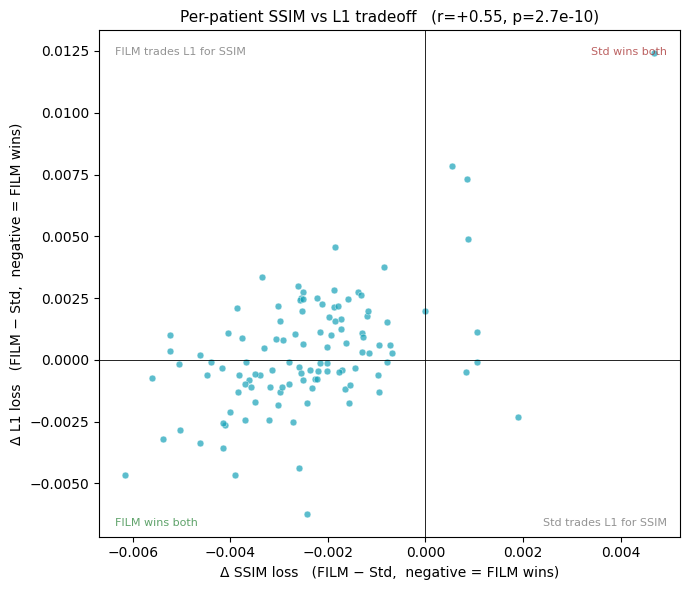

FILM wins both:         56 / 113
FILM loses both:         5 / 113
FILM trades L1→SSIM:    49 / 113


In [514]:
ssim_w = _wide(losses, 'ssim_loss')
l1_w   = _wide(losses, 'l1_loss')
delta_ssim = (ssim_w['f'] - ssim_w['s']).rename('delta_ssim')
delta_l1   = (l1_w['f']   - l1_w['s']  ).rename('delta_l1')
trade = pd.concat([delta_ssim, delta_l1], axis=1)

r_pearson, p_pearson = stats.pearsonr(trade['delta_ssim'], trade['delta_l1'])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(trade['delta_ssim'], trade['delta_l1'],
           s=24, alpha=0.7, c=FILM_COLOR, edgecolors='white', linewidths=0.4)
ax.axhline(0, color='black', lw=0.6); ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Δ SSIM loss   (FILM − Std,  negative = FILM wins)')
ax.set_ylabel('Δ L1 loss   (FILM − Std,  negative = FILM wins)')
ax.set_title(f'Per-patient SSIM vs L1 tradeoff   (r={r_pearson:+.2f}, p={p_pearson:.2g})',
             fontsize=11)

# Quadrant annotations
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[0]*0.95, ylim[0]*0.95, 'FILM wins both', fontsize=8,
        ha='left', va='bottom', color='#1c7c2c', alpha=0.7)
ax.text(xlim[1]*0.95, ylim[1]*0.95, 'Std wins both', fontsize=8,
        ha='right', va='top', color='#a02020', alpha=0.7)
ax.text(xlim[0]*0.95, ylim[1]*0.95, 'FILM trades L1 for SSIM', fontsize=8,
        ha='left', va='top', color='#666666', alpha=0.7)
ax.text(xlim[1]*0.95, ylim[0]*0.95, 'Std trades L1 for SSIM', fontsize=8,
        ha='right', va='bottom', color='#666666', alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'tradeoff_ssim_vs_l1.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnostic counts
n_both_win  = ((trade['delta_ssim'] < 0) & (trade['delta_l1'] < 0)).sum()
n_both_lose = ((trade['delta_ssim'] > 0) & (trade['delta_l1'] > 0)).sum()
n_trade     = (((trade['delta_ssim'] < 0) & (trade['delta_l1'] > 0))).sum()
print(f'FILM wins both:        {n_both_win:3d} / {len(trade)}')
print(f'FILM loses both:       {n_both_lose:3d} / {len(trade)}')
print(f'FILM trades L1→SSIM:   {n_trade:3d} / {len(trade)}')


## 11 — Clinical-axis stratification

Four clinically meaningful axes instead of 22. Each panel shows mean ΔSSIM+L1
loss per bin, with paired t-test p-value annotated on bins where significant.

Axes chosen:
- **Age** (`BirthYear` tertiles — younger / mid / older)
- **WMH burden** (`wmh_volume` tertiles — low / mid / high)
- **Sex** (binary)
- **Smoking status** (categorical levels)


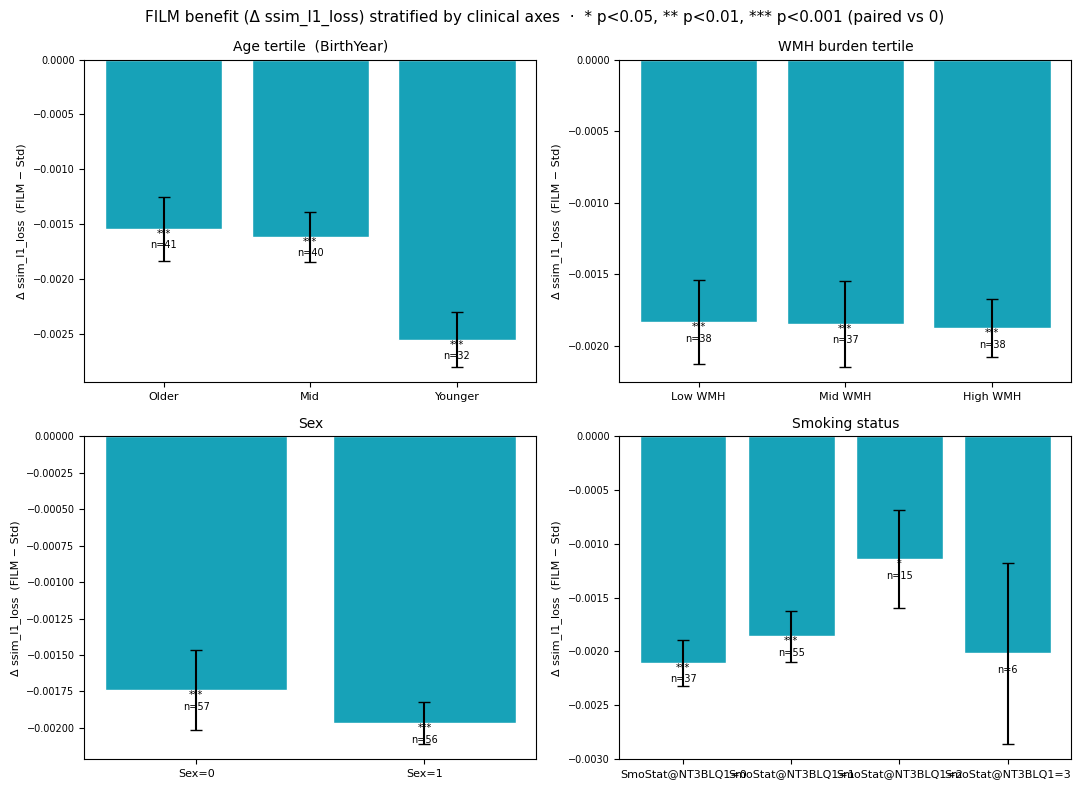

In [515]:
def _patient_deltas():
    w = _wide(losses, 'ssim_l1_loss')
    return (w['f'] - w['s']).rename('delta')

dpat = _patient_deltas()  # series indexed by hunt_id

def _bin_clinical(meta_test, feature, kind, n_bins=3, labels=None):
    if kind == 'continuous':
        labels = labels or [f'{feature}\nT{i+1}' for i in range(n_bins)]
        return pd.qcut(meta_test.set_index('hunt_id')[feature], q=n_bins,
                       labels=labels, duplicates='drop')
    # categorical / binary — return integer level as label
    s = meta_test.set_index('hunt_id')[feature]
    return s.map(lambda v: f'{feature}={int(v)}' if pd.notna(v) else None)

def _bar_axis(ax, bin_series, deltas, axis_title):
    df = pd.concat([bin_series.rename('bin'), deltas.rename('delta')], axis=1).dropna()
    grouped = df.groupby('bin', observed=True)['delta']
    means = grouped.mean()
    sems  = grouped.std(ddof=1) / np.sqrt(grouped.size())
    ns    = grouped.size()
    bars  = ax.bar(range(len(means)), means.values, yerr=sems.values,
                   color=[FILM_COLOR if m < 0 else STD_COLOR for m in means.values],
                   capsize=4, edgecolor='white')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([str(x) for x in means.index], fontsize=8, rotation=0)
    ax.set_ylabel('Δ ssim_l1_loss  (FILM − Std)', fontsize=8)
    ax.set_title(axis_title, fontsize=10)
    # Paired t-test per bin (Δ vs 0)
    for i, (name, vals) in enumerate(grouped):
        t, p = stats.ttest_1samp(vals, 0.0)
        sig  = '*' if p < 0.05 else ''
        sig += '*' if p < 0.01 else ''
        sig += '*' if p < 0.001 else ''
        ax.text(i, means[name], f'{sig}\nn={int(ns[name])}',
                ha='center', va='bottom' if means[name] >= 0 else 'top', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
_bar_axis(axes[0,0], _bin_clinical(meta_test, 'BirthYear', 'continuous',
                                    labels=['Older', 'Mid', 'Younger']),
          dpat, 'Age tertile  (BirthYear)')
_bar_axis(axes[0,1], _bin_clinical(meta_test, 'wmh_volume', 'continuous',
                                    labels=['Low WMH', 'Mid WMH', 'High WMH']),
          dpat, 'WMH burden tertile')
_bar_axis(axes[1,0], _bin_clinical(meta_test, 'Sex', 'binary'),
          dpat, 'Sex')
_bar_axis(axes[1,1], _bin_clinical(meta_test, 'SmoStat@NT3BLQ1', 'categorical'),
          dpat, 'Smoking status')
plt.suptitle('FILM benefit (Δ ssim_l1_loss) stratified by clinical axes  ·  '
             '* p<0.05, ** p<0.01, *** p<0.001 (paired vs 0)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clinical_axes_stratification.png', dpi=150, bbox_inches='tight')
plt.show()


## 12 — Does FILM actually use its features?

If FILM's gain is driven by the conditioning (and not just regularization),
patients whose features fall in particular ranges should show larger gains.
For each of the 22 FILM-input features, scatter the per-patient feature value
against the per-patient ΔSSIM+L1 loss. Pearson r is annotated; significant
(|r|≥0.2) panels are highlighted.

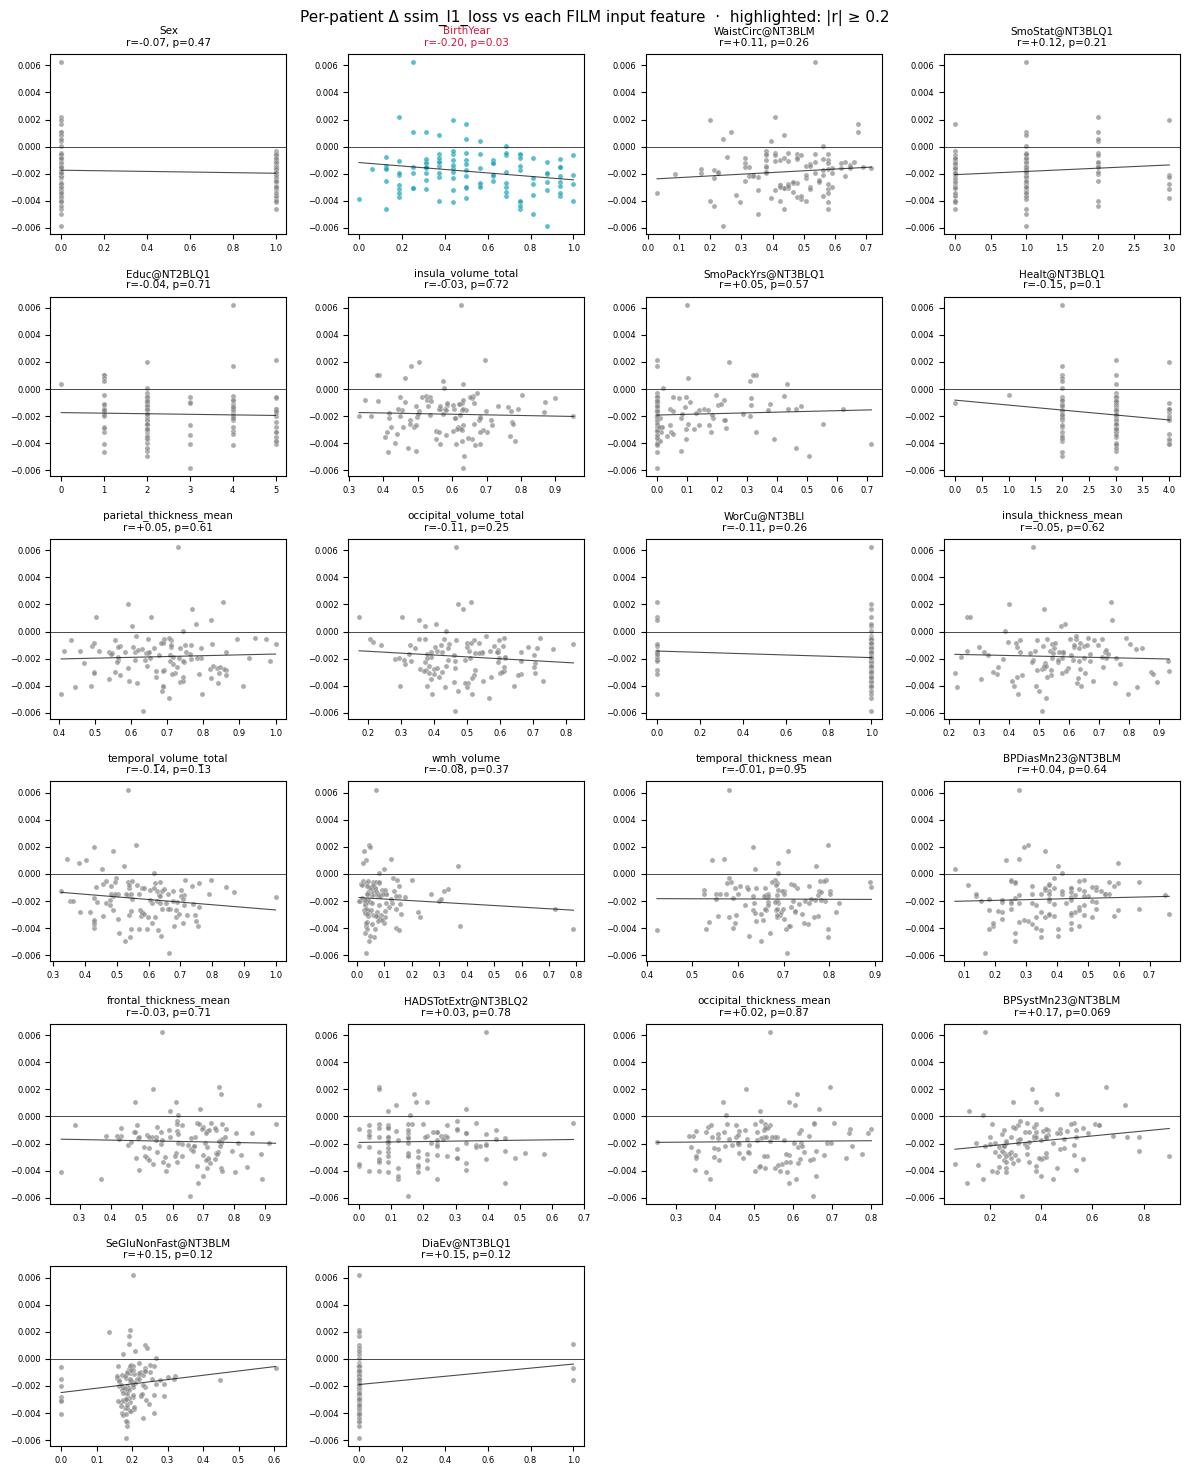

Strongest negative correlations (FILM gains more when feature is HIGH):
               feature         r        p   n
             BirthYear -0.203681 0.030478 113
         Healt@NT3BLQ1 -0.154591 0.102069 113
 temporal_volume_total -0.142380 0.132487 113
occipital_volume_total -0.108992 0.250497 113
          WorCu@NT3BLI -0.105992 0.263852 113

Strongest positive correlations (FILM gains more when feature is LOW):
            feature        r        p   n
   WaistCirc@NT3BLM 0.106862 0.259929 113
    SmoStat@NT3BLQ1 0.119268 0.208308 113
SeGluNonFast@NT3BLM 0.147021 0.120201 113
      DiaEv@NT3BLQ1 0.148519 0.116428 113
  BPSystMn23@NT3BLM 0.171594 0.069172 113


In [516]:
# Use normalized values from metadata_combined.csv — they're already loaded as `meta`.
# FILM_22 features all exist as columns in `meta_test` (some as one-hot for cat'l;
# recovered integer level for those is also present from §2).

mt = meta_test.set_index('hunt_id')

ncols = 4
nrows = (len(FILM_22) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 2.5*nrows))
axes = axes.flatten()

corr_rows = []
for i, feat in enumerate(FILM_22):
    ax = axes[i]
    x = mt[feat].reindex(dpat.index)
    y = dpat
    mask = x.notna() & y.notna()
    x = x[mask]; y = y[mask]
    if x.nunique() < 2 or len(x) < 5:
        ax.set_visible(False); continue
    r, p = stats.pearsonr(x.values, y.values)
    color = FILM_COLOR if abs(r) >= 0.2 else '#888888'
    ax.scatter(x, y, s=14, alpha=0.7, c=color, edgecolors='white', linewidths=0.3)
    ax.axhline(0, color='black', lw=0.5)
    # Trend line
    coef = np.polyfit(x.values, y.values, 1)
    xr = np.array([x.min(), x.max()])
    ax.plot(xr, coef[0]*xr + coef[1], color='black', lw=0.8, alpha=0.7)
    title_color = 'crimson' if abs(r) >= 0.2 else 'black'
    ax.set_title(f'{feat}\nr={r:+.2f}, p={p:.2g}',
                 fontsize=7.5, color=title_color)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(''); ax.set_ylabel('')
    corr_rows.append({'feature':feat, 'r':r, 'p':p, 'n':len(x)})

for j in range(len(FILM_22), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Per-patient Δ ssim_l1_loss vs each FILM input feature  ·  '
             'highlighted: |r| ≥ 0.2', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'film_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

corr_tbl = pd.DataFrame(corr_rows).sort_values('r')
print('Strongest negative correlations (FILM gains more when feature is HIGH):')
print(corr_tbl.head(5).to_string(index=False))
print()
print('Strongest positive correlations (FILM gains more when feature is LOW):')
print(corr_tbl.tail(5).to_string(index=False))


## 13 — Qualitative patient cases

Three patients picked from the test set:
1. **Biggest FILM gain** — patient with the most negative Δ ssim_l1_loss
2. **Biggest FILM regression** — patient with the most positive Δ ssim_l1_loss
3. **Median patient** — patient closest to the median Δ

For each, show input (HUNT3 T1), ground truth (HUNT4 T1), Std prediction, FILM
prediction, and a difference map. Axial mid-slice.

Selected cases:
  biggest_film_gain         → hunt_id=19707  Δ=-0.00585
  biggest_film_regression   → hunt_id=11128  Δ=+0.00622
  median_patient            → hunt_id=25219  Δ=-0.00188


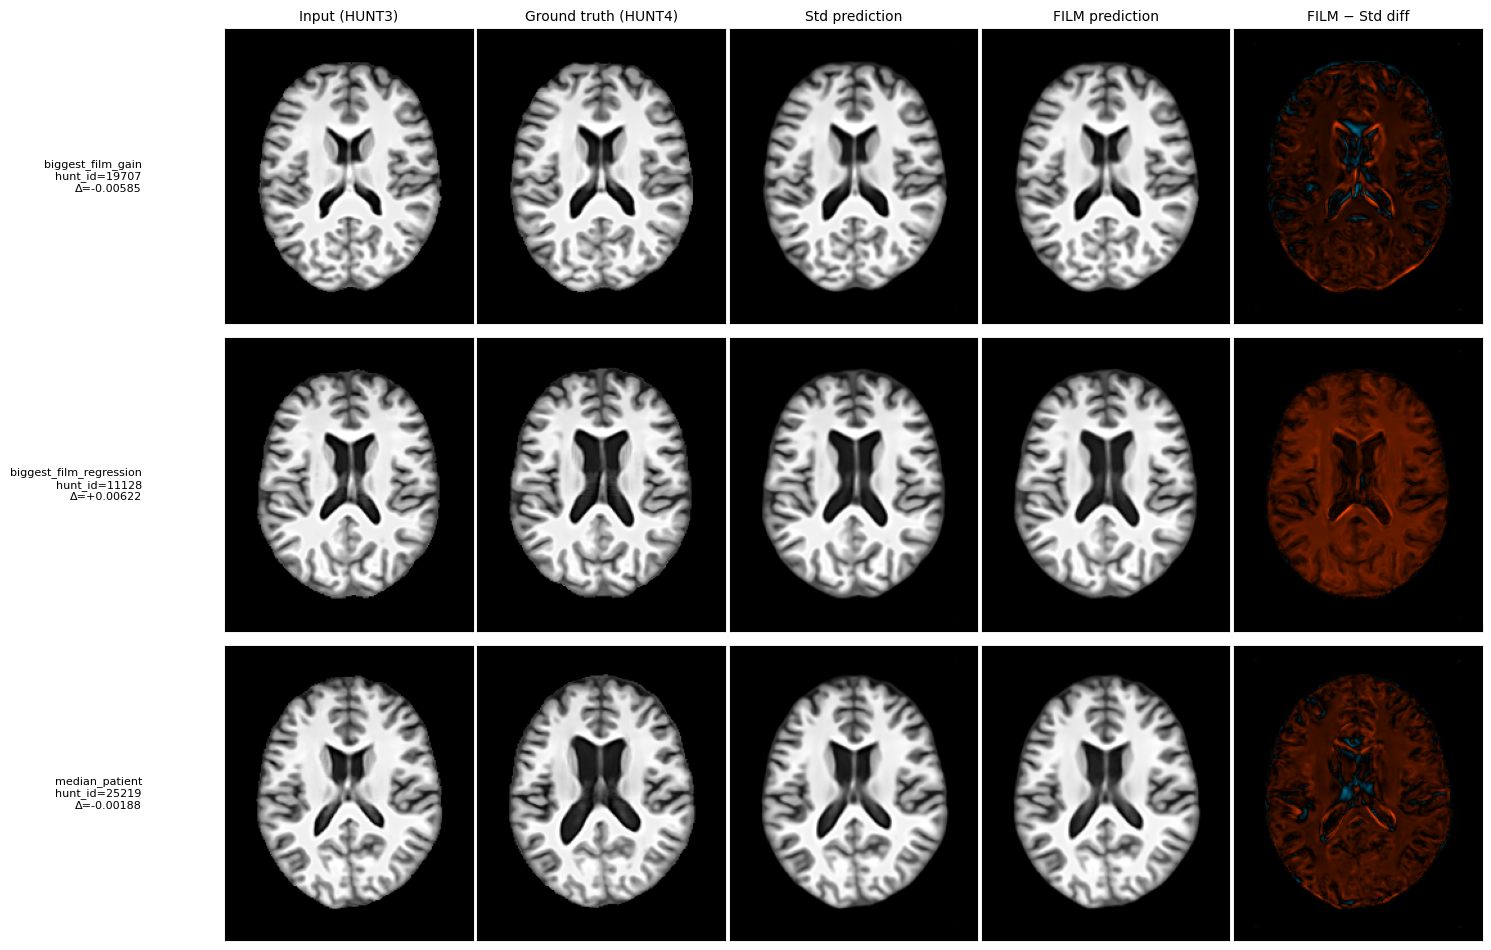

In [521]:
import nibabel as nib
from matplotlib.colors import LinearSegmentedColormap

dpat_sorted = dpat.sort_values()

cases = {
    'biggest_film_gain'     : dpat_sorted.index[0],
    'biggest_film_regression': dpat_sorted.index[-1],
    'median_patient'        : dpat_sorted.iloc[(dpat_sorted - dpat_sorted.median()).abs().argsort()].index[0],
}
print('Selected cases:')
for k, pid in cases.items():
    print(f'  {k:25s} → hunt_id={pid}  Δ={dpat[pid]:+.5f}')

def _slice(p):
    return nib.load(str(p)).get_fdata()[:, :, 96]  # axial mid-slice

def _norm01(x):
    x = x.astype(float)
    lo, hi = np.nanpercentile(x, [1, 99])
    return np.clip((x - lo) / max(hi - lo, 1e-9), 0, 1)

# Diverging colormap: blue → black (at 0) → red.
# Unlike magma, the midpoint here is truly black so zero-diff regions are invisible.
_diff_cmap = LinearSegmentedColormap.from_list(
    'bkr', ['deepskyblue', 'black', 'orangered']
)

fig, axes = plt.subplots(len(cases), 5, figsize=(15, 3.2 * len(cases)))
for row_i, (case_name, pid) in enumerate(cases.items()):
    hunt3_t1 = _slice(Path('data/HUNT3') / pid / f'{pid}_0_T1_PREP_MNI.nii.gz')
    hunt4_t1 = _slice(Path('data/HUNT4') / pid / f'{pid}_1_T1_PREP_MNI.nii.gz')
    std_pred  = _slice(STD_DIR  / 'predictions' / f'{pid}_pred.nii.gz')
    film_pred = _slice(FILM_DIR / 'predictions' / f'{pid}_pred.nii.gz')
    diff      = film_pred - std_pred

    for col_i, (img, title, kw) in enumerate([
        (hunt3_t1, 'Input (HUNT3)',        {'cmap':'gray',   'norm_pct':True}),
        (hunt4_t1, 'Ground truth (HUNT4)', {'cmap':'gray',   'norm_pct':True}),
        (std_pred, 'Std prediction',       {'cmap':'gray',   'norm_pct':True}),
        (film_pred,'FILM prediction',      {'cmap':'gray',   'norm_pct':True}),
        (diff,     'FILM − Std diff',      {'cmap':_diff_cmap, 'sym':True}),
    ]):
        ax = axes[row_i, col_i]
        plot_img = _norm01(img) if kw.get('norm_pct') else img
        if kw.get('sym'):
            vmax = max(abs(np.nanmin(diff)), abs(np.nanmax(diff)), 1e-6)
            ax.imshow(np.rot90(plot_img), cmap=kw['cmap'], vmin=-vmax, vmax=vmax)
        else:
            ax.imshow(np.rot90(plot_img), cmap=kw['cmap'])
        ax.set_xticks([]); ax.set_yticks([])
        if row_i == 0:
            ax.set_title(title, fontsize=10)
    delta_val = dpat[pid]
    axes[row_i, 0].set_ylabel(f'{case_name}\nhunt_id={pid}\nΔ={delta_val:+.5f}',
                              fontsize=8, rotation=0, labelpad=60, ha='right', va='center')

plt.tight_layout()
plt.savefig(FIG_DIR / 'qualitative_patient_cases.png', dpi=150, bbox_inches='tight')
plt.show()


---
### Output files

`out/overleaf_figures/ex4/`
- `ex4_summary_tables.tex` — per-tissue summary tables
- `tradeoff_ssim_vs_l1.png`
- `clinical_axes_stratification.png`
- `film_feature_correlations.png`
- `qualitative_patient_cases.png`
